# Company Key Variables

Use this notebook to inspect the most important annual financial statement values for one public company.

The tables and charts use **USD billions** so the unit is clear and large accounting values are easier to compare.

What you can change:

- `ticker`: one Yahoo Finance symbol, for example `AAPL`, `MSFT`, or `NVDA`.
- `years`: number of recent annual fiscal periods to show.

This notebook focuses on variables such as revenue, profits, cash flow, cash, short-term debt, long-term debt, assets, liabilities, equity, and working capital.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

# Find the project root whether this notebook is opened from the repo root
# or from quick_views/notebooks.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next(path for path in candidates if (path / "utils.py").exists())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from quick_views.company_financial_overview import (
    build_company_financial_overview,
    format_billions_frame,
    latest_values,
    plot_key_variables,
    to_billions,
)

def format_billions(value):
    """Format one USD-billions value without requiring pandas Styler/jinja2."""
    if pd.isna(value):
        return ""
    return f"{value:,.1f}"

print(f"Project root: {project_root}")

Project root: C:\Users\lnazareno\OneDrive - European Banking Authority\Documents\Projects\financial_analysis


## Inputs

Edit this cell and rerun the cells below.

In [2]:
ticker = "AAPL"
years = 4

## Latest Values

This table shows the newest annual values available from Yahoo Finance. The unit is USD billions.

In [3]:
overview = build_company_financial_overview(ticker)

latest_variable_table = format_billions_frame(latest_values(overview.variables)).to_frame("USD billions")
display(latest_variable_table)

,USD billions
Revenue,416.2
Gross Profit,195.2
Operating Income,133.1
EBITDA,144.7
EBIT,133.1
Net Income,112.0
R&D Expense,34.5
SG&A Expense,27.6
Cost Of Revenue,221.0
Operating Cash Flow,111.5


## Recent History

Use this table to see whether sales, profits, cash flow, debt, assets, and equity are rising or falling over time. The unit is USD billions.

In [4]:
variables_recent = overview.variables.tail(years)
variables_recent_billions = to_billions(variables_recent)
variables_recent_display = variables_recent_billions.map(format_billions)

display(variables_recent_display)

,Revenue,Gross Profit,Operating Income,EBITDA,EBIT,Net Income,R&D Expense,SG&A Expense,Cost Of Revenue,Operating Cash Flow,...,Total Assets,Current Liabilities,Short Term Debt,Long Term Debt,Total Debt,Net Debt,Total Liabilities,Stockholders Equity,Invested Capital,Working Capital
2022-09-30,394.3,170.8,119.4,130.5,119.4,99.8,26.3,25.1,223.5,122.2,...,352.8,154.0,22.8,109.7,132.5,96.4,302.1,50.7,170.7,-18.6
2023-09-30,383.3,169.1,114.3,125.8,114.3,97.0,29.9,24.9,214.1,110.5,...,352.6,145.3,15.8,95.3,111.1,81.1,290.4,62.1,173.2,-1.7
2024-09-30,391.0,180.7,123.2,134.7,123.2,93.7,31.4,26.1,210.4,118.3,...,365.0,176.4,20.9,85.8,106.6,76.7,308.0,57.0,163.6,-23.4
2025-09-30,416.2,195.2,133.1,144.7,133.1,112.0,34.5,27.6,221.0,111.5,...,359.2,165.6,20.3,78.3,98.7,62.7,285.5,73.7,172.4,-17.7


## Chart

The chart splits variables into related groups. Each y-axis is labeled in USD billions, so values can be read without scientific notation.

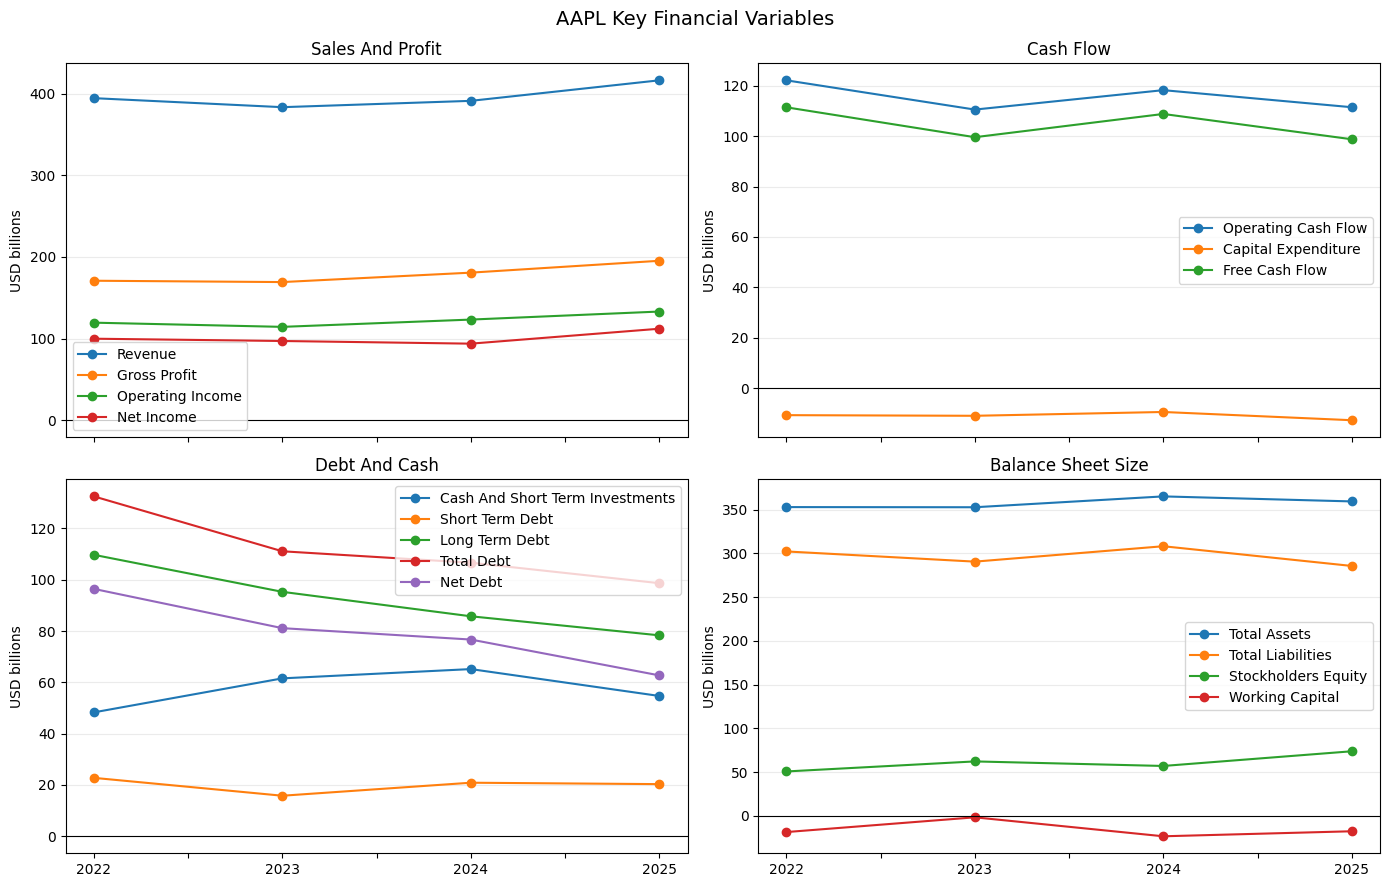

In [5]:
plot_key_variables(ticker, overview.variables, years)